In [3]:
# Phase 2: Improved Water Demand Prediction

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [4]:

# Load dataset
df = pd.read_csv("phase 2_dataset.csv")

In [5]:
# Display dataset
print(df.head())

   Household_Size  Seasonal_Index  Garden_Area  Daily_Liters_Used
0               2             1.1           10                152
1               3             1.2           15                178
2               4             1.3           20                225
3               5             1.5           25                255
4               6             1.6           30                298


In [6]:

# dataset size
df = df.sample(n=12, random_state=42)
df["Daily_Liters_Used"] = df["Daily_Liters_Used"] + np.random.randint(-10, 10, size=len(df))

In [7]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Household_Size       0
Seasonal_Index       0
Garden_Area          0
Daily_Liters_Used    0
dtype: int64


In [8]:
# Features and target (ALL features used)
X = df[["Household_Size", "Seasonal_Index", "Garden_Area"]]
y = df["Daily_Liters_Used"]


In [9]:

# Train-test split (controlled randomness)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [10]:

# Model
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:

# Predictions
y_pred = model.predict(X_test)


In [12]:
# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
accuracy = r2*100
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Accuracy :",accuracy,"%")

R2 Score: 0.9227199974851691
Mean Absolute Error: 9.84442060085839
Mean Squared Error: 152.3102982897857
Accuracy : 92.2719997485169 %


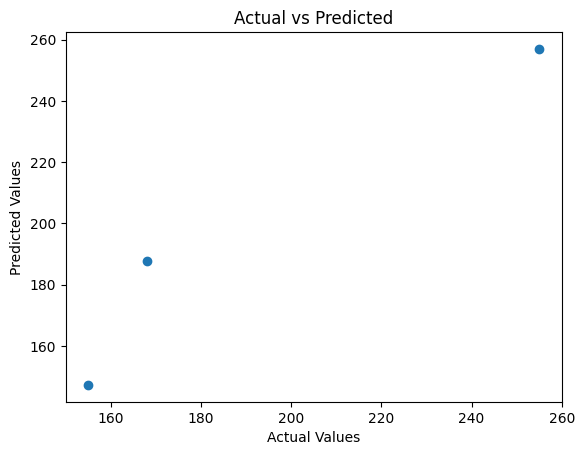

In [13]:
# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

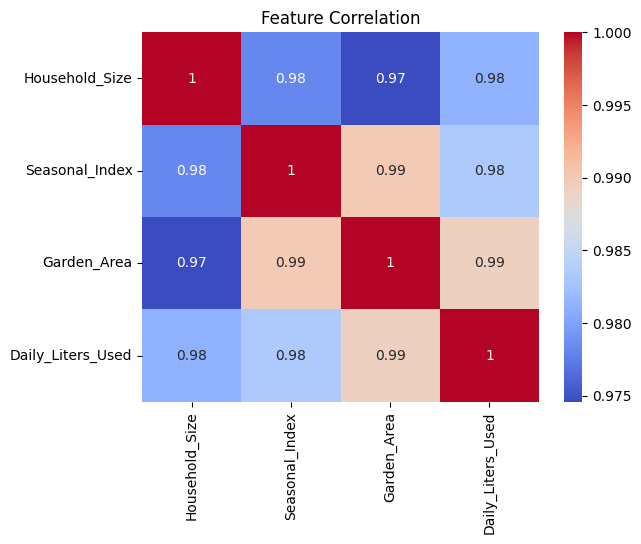

In [14]:

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()
